In [1]:
#import data into python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\MEFACHURCH\OneDrive\Documents\Vehicule_Data\Vehicle Data.csv")

In [54]:
df.head()

,State,Electric (EV),Plug-In Hybrid Electric (PHEV),Hybrid Electric (HEV),Biodiesel,Ethanol/Flex (E85),Compressed Natural Gas (CNG),Propane,Hydrogen,Methanol,Gasoline,Diesel,Unknown Fuel
0,Alabama,13000,5800,63300,54200,441200,100,100,0,0,4102200,127000,29000
1,Alaska,2700,900,10600,9600,46800,0,0,0,0,454300,29800,5100
2,Arizona,89800,25600,175700,68600,437100,600,700,0,0,5469000,197700,64200
3,Arkansas,7100,3200,37000,37000,276700,200,0,0,0,2246100,90700,10300
4,California,1256600,410700,1703200,201600,1314600,10100,1500,16900,0,31191900,735300,7900


In [40]:
rows = df.shape[0]
columns = df.shape[1]
print(rows)
print(columns)

51
17


In [4]:
df.rename(columns ={ 'Electric (EV)' : 'EV' , 
                    'Plug-In Hybrid Electric (PHEV)' : 'PHEV',
                    'Hybrid Electric (HEV)' : 'HEV',
                    'Ethanol/Flex (E85)' : 'Ethanol_E85',
                    'Compressed Natural Gas (CNG)' : 'CNG',
                   'Unknown Fuel' : 'Unknown_Fuel'} , inplace = True
         )
                    

In [5]:
# check for duplicates and missing values
df.isnull().sum()

State           0
EV              0
PHEV            0
HEV             0
Biodiesel       0
Ethanol_E85     0
CNG             0
Propane         0
Hydrogen        0
Methanol        0
Gasoline        0
Diesel          0
Unknown_Fuel    0
dtype: int64

In [6]:
df[df.duplicated()]
#no duplicates found

,State,EV,PHEV,HEV,Biodiesel,Ethanol_E85,CNG,Propane,Hydrogen,Methanol,Gasoline,Diesel,Unknown_Fuel


In [65]:
#check data_types
df.dtypes

State           object
EV               int64
PHEV             int64
HEV              int64
Biodiesel        int64
Ethanol_E85      int64
CNG              int64
Propane          int64
Hydrogen         int64
Methanol         int64
Gasoline         int64
Diesel           int64
Unknown_Fuel     int64
dtype: object

In [66]:
# calculate percentage of EVs PHEVs , HEVs and Gasoline for each state
df.head()

,State,EV,PHEV,HEV,Biodiesel,Ethanol_E85,CNG,Propane,Hydrogen,Methanol,Gasoline,Diesel,Unknown_Fuel
0,Alabama,13000,5800,63300,54200,441200,100,100,0,0,4102200,127000,29000
1,Alaska,2700,900,10600,9600,46800,0,0,0,0,454300,29800,5100
2,Arizona,89800,25600,175700,68600,437100,600,700,0,0,5469000,197700,64200
3,Arkansas,7100,3200,37000,37000,276700,200,0,0,0,2246100,90700,10300
4,California,1256600,410700,1703200,201600,1314600,10100,1500,16900,0,31191900,735300,7900


In [7]:
df.columns

Index(['State', 'EV', 'PHEV', 'HEV', 'Biodiesel', 'Ethanol_E85', 'CNG',
       'Propane', 'Hydrogen', 'Methanol', 'Gasoline', 'Diesel',
       'Unknown_Fuel'],
      dtype='object')

In [8]:
# Market share by fuel

All_vehicles = ['EV', 'PHEV', 'HEV', 'Biodiesel', 'Ethanol_E85', 'CNG', 'Propane',
       'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown_Fuel']

sum_of_all_vehicles = (df[All_vehicles].sum()).sum()

Market_share = (df[All_vehicles].sum(axis = 0)/ sum_of_all_vehicles*100).sort_values(ascending = False).round(2)

print(f"\n{"="*38}")
print("Vehicule Fuel Market Share in the US")
print ("="*38)
print(Market_share)


Vehicule Fuel Market Share in the US
Gasoline        84.60
Ethanol_E85      7.05
HEV              2.57
Diesel           2.50
EV               1.24
Biodiesel        0.98
Unknown_Fuel     0.59
PHEV             0.46
CNG              0.01
Hydrogen         0.01
Propane          0.00
Methanol         0.00
dtype: float64


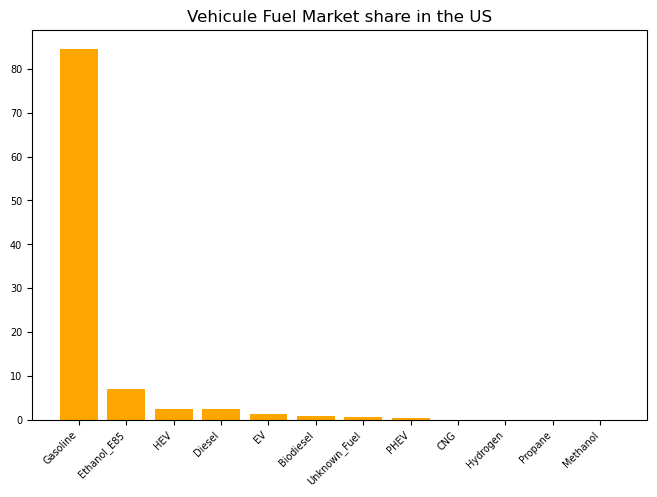

In [38]:
# graph
Fuel = ['Gasoline', 'Ethanol_E85', 'HEV', 'Diesel', 'EV', 'Biodiesel', 'Unknown_Fuel', 'PHEV', 'CNG', 'Hydrogen', 'Propane', 'Methanol']
Market_share = [84.60, 7.05, 2.57, 2.50, 1.24, 0.98, 0.59, 0.46, 0.01, 0.01, 0.00, 0.00]

plt.bar(Fuel, Market_share, color = 'orange')
plt.title("Vehicule Fuel Market share in the US") 
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout(pad = 0.1)
plt.savefig("Vehicle Market share in the US", dpi=300, bbox_inches='tight')
plt.show()

In [71]:
# Percent EV, PHEV, HEV by State

df['Total_vehicles'] = df[['EV', 'PHEV', 'HEV', 'Biodiesel', 'Ethanol_E85', 'CNG', 'Propane',
       'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown_Fuel']].sum(axis =1)

df['EV_Pct'] = (df['EV']/df['Total_vehicles']*100).round(2)

Result1 = df.sort_values(by = 'EV_Pct', ascending = False) 
print(f"\n{"="*43}")
print("Percentage Vehicule Electric share by State")
print ("="*43)
print(Result1[['State', 'EV_Pct']].to_string(index=False))


Percentage Vehicule Electric share by State
               State  EV_Pct
          California    3.41
District of Columbia    2.60
              Hawaii    2.37
          Washington    2.23
              Nevada    1.85
          New Jersey    1.84
              Oregon    1.68
            Colorado    1.66
            Maryland    1.42
             Arizona    1.38
             Florida    1.37
       Massachusetts    1.34
             Vermont    1.32
                Utah    1.30
            New York    1.16
            Virginia    1.10
         Connecticut    1.07
            Illinois    0.99
             Georgia    0.96
            Delaware    0.92
               Texas    0.89
      North Carolina    0.77
        Rhode Island    0.73
           Minnesota    0.72
       New Hampshire    0.72
        Pennsylvania    0.69
               Maine    0.60
            Michigan    0.59
            Oklahoma    0.53
          New Mexico    0.53
           Tennessee    0.51
                Ohio    0.4

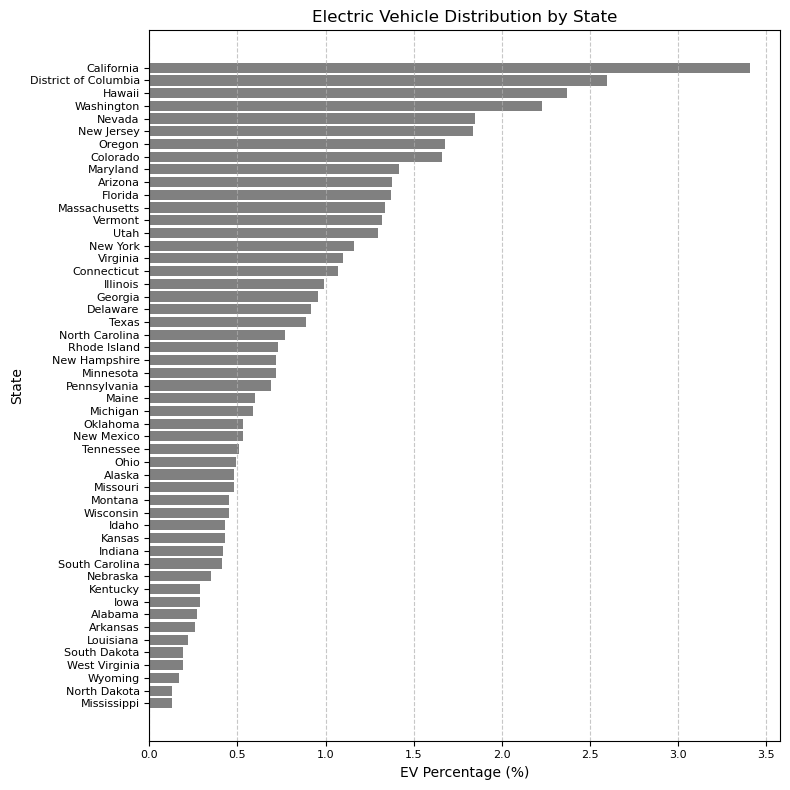

In [91]:
# insert chart 
Result1 = Result1.sort_values(by="EV_Pct", ascending=True)

plt.figure(figsize=(8, 8))  # Increase figure size

# Create horizontal bar chart
plt.barh(Result1["State"], Result1["EV_Pct"], color = "gray")

# Improve labels
plt.xlabel("EV Percentage (%)")
plt.ylabel("State")
plt.title("Electric Vehicle Distribution by State")

# Reduce number of x-ticks
plt.xticks(fontsize=8)

# Improve y-axis readability
plt.yticks(fontsize=8)

# Add grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("ev_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# insert comment

In [96]:
# PHEV distribution in US

df['Total_vehicles'] = df[['EV', 'PHEV', 'HEV', 'Biodiesel', 'Ethanol_E85', 'CNG', 'Propane',
       'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown_Fuel']].sum(axis =1)

df['PHEV_Pct'] = (df['PHEV']/df['Total_vehicles']*100).round(2)

Result2 = df.sort_values(by = 'PHEV_Pct', ascending = False) 
print(f"\n{"="*30}")
print("Percentage PHEV share by State")
print ("="*30)
print(Result2[['State', 'PHEV_Pct']].to_string(index=False))


Percentage PHEV share by State
               State  PHEV_Pct
District of Columbia      1.19
          California      1.11
             Vermont      0.96
            New York      0.82
       Massachusetts      0.80
            Oklahoma      0.77
              Oregon      0.75
            Colorado      0.69
              Hawaii      0.68
         Connecticut      0.62
            Maryland      0.62
               Maine      0.61
          Washington      0.60
        Rhode Island      0.58
          New Jersey      0.56
       New Hampshire      0.48
            Delaware      0.42
                Utah      0.42
              Nevada      0.41
             Arizona      0.39
        Pennsylvania      0.38
            Virginia      0.35
            Michigan      0.34
            Illinois      0.33
             Florida      0.31
           Minnesota      0.31
      North Carolina      0.26
            Missouri      0.25
          New Mexico      0.25
             Georgia      0.24
       

In [ ]:
#insert comments

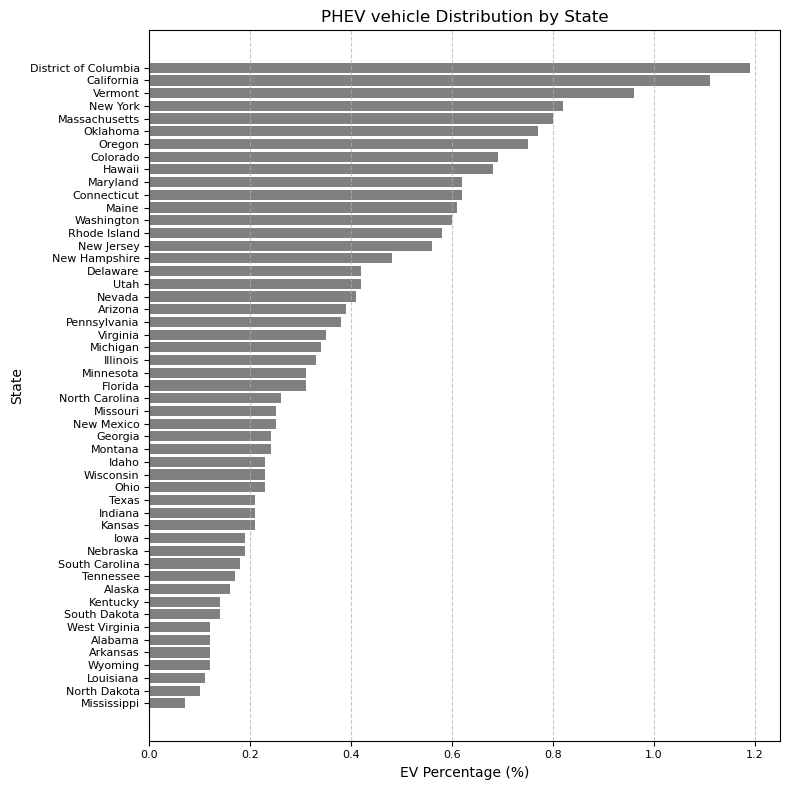

In [100]:
Result2 = Result2.sort_values(by="PHEV_Pct", ascending=True)

plt.figure(figsize=(8, 8))  # Increase figure size

# Create horizontal bar chart
plt.barh(Result2["State"], Result2["PHEV_Pct"], color = "gray")

# Improve labels
plt.xlabel("EV Percentage (%)")
plt.ylabel("State")
plt.title("PHEV vehicle Distribution by State")

# Reduce number of x-ticks
plt.xticks(fontsize=8)

# Improve y-axis readability
plt.yticks(fontsize=8)

# Add grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("PHEV_Vehicle_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

In [12]:
# HEV distribution by state

df['Total_vehicles'] = df[['EV', 'PHEV', 'HEV', 'Biodiesel', 'Ethanol_E85', 'CNG', 'Propane',
       'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown_Fuel']].sum(axis =1)

df['HEV_Pct'] = (df['HEV']/df['Total_vehicles']*100).round(2)

Result3 = df.sort_values(by = 'HEV_Pct', ascending = False) 
print(f"\n{"="*38}")
print("Percentage HEV share by State")
print ("="*38)
print(Result3[['State', 'HEV_Pct']].to_string(index=False))


Percentage HEV share by State
               State  HEV_Pct
District of Columbia     5.80
          California     4.62
          Washington     4.51
              Oregon     4.09
             Vermont     3.42
       Massachusetts     3.41
              Hawaii     3.37
            Maryland     3.33
            Virginia     2.97
            Illinois     2.84
            Colorado     2.81
            New York     2.77
              Nevada     2.72
               Maine     2.72
                Utah     2.70
             Arizona     2.69
       New Hampshire     2.66
         Connecticut     2.56
        Rhode Island     2.52
            Delaware     2.50
           Minnesota     2.43
        Pennsylvania     2.40
          New Jersey     2.38
      North Carolina     2.32
          New Mexico     2.27
           Wisconsin     2.24
             Florida     2.23
               Idaho     2.21
             Montana     2.07
            Missouri     2.02
                Ohio     1.94
         

In [ ]:
# insert comments

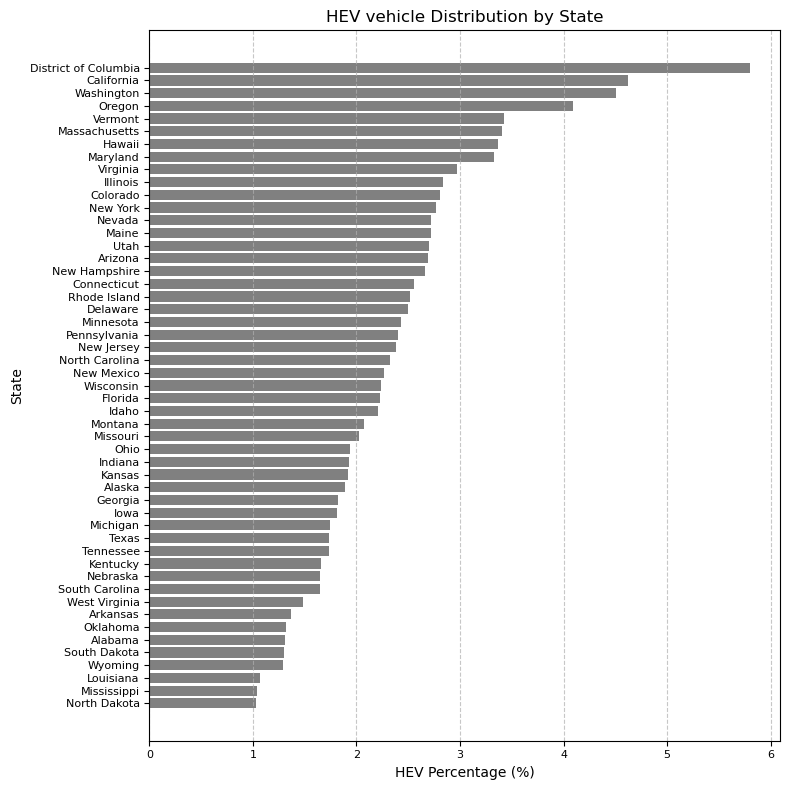

In [16]:
Result3 = Result3.sort_values(by="HEV_Pct", ascending=True)

plt.figure(figsize=(8, 8))  # Increase figure size

# Create horizontal bar chart
plt.barh(Result3["State"], Result3["HEV_Pct"], color = "gray")

# Improve labels
plt.xlabel("HEV Percentage (%)")
plt.ylabel("State")
plt.title("HEV vehicle Distribution by State")

# Reduce number of x-ticks
plt.xticks(fontsize=8)

# Improve y-axis readability
plt.yticks(fontsize=8)

# Add grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("HEV_Vehicle_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

In [19]:
# Gasoline distribution

df['Total_vehicles'] = df[['EV', 'PHEV', 'HEV', 'Biodiesel', 'Ethanol_E85', 'CNG', 'Propane',
       'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown_Fuel']].sum(axis =1)

df['Gasoline_Pct'] = (df['Gasoline']/df['Total_vehicles']*100).round(2)

Result4 = df.sort_values(by = 'Gasoline_Pct', ascending = False) 
print(f"\n{"="*38}")
print("Percentage Gasoline share by State")
print ("="*38)
print(Result3[['State', 'Gasoline_Pct']].to_string(index=False))


Percentage Gasoline share by State
               State  Gasoline_Pct
        Rhode Island         89.11
         Connecticut         88.69
              Hawaii         88.05
          New Jersey         87.83
            New York         87.52
       Massachusetts         87.26
        Pennsylvania         87.03
             Florida         86.83
            Delaware         86.51
            Virginia         86.36
                Ohio         86.08
           Tennessee         85.96
      South Carolina         85.77
       New Hampshire         85.66
             Georgia         85.63
            Maryland         85.53
      North Carolina         85.45
            Illinois         85.23
              Nevada         84.87
             Alabama         84.83
       West Virginia         84.82
          California         84.64
            Kentucky         84.54
District of Columbia         84.11
               Maine         83.83
             Arizona         83.76
             Indian

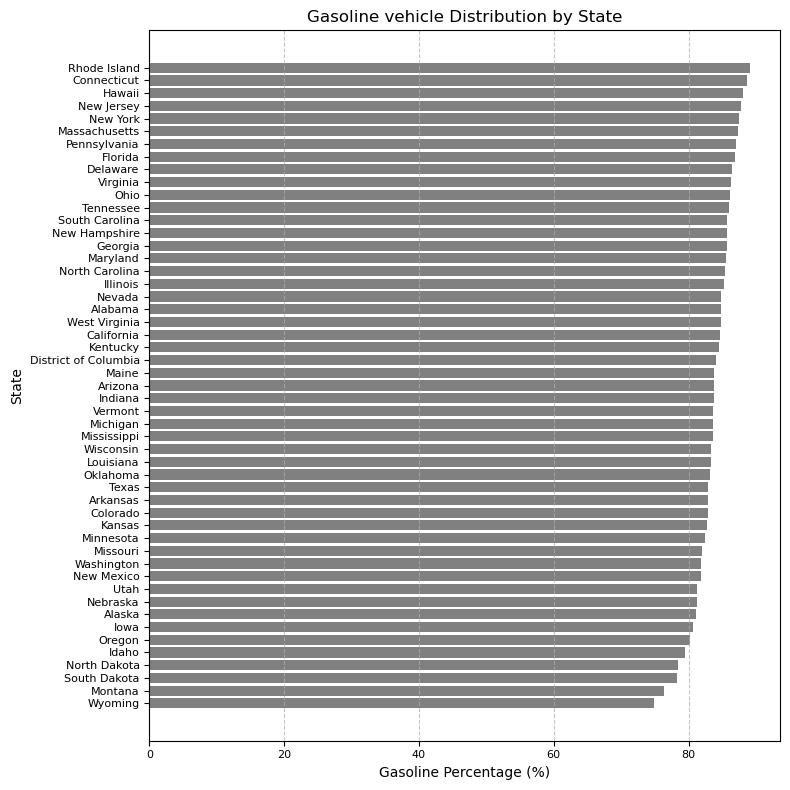

In [20]:
Result4 = Result4.sort_values(by="Gasoline_Pct", ascending=True)

plt.figure(figsize=(8, 8))  # Increase figure size

# Create horizontal bar chart
plt.barh(Result4["State"], Result4["Gasoline_Pct"], color = "gray")

# Improve labels
plt.xlabel("Gasoline Percentage (%)")
plt.ylabel("State")
plt.title("Gasoline vehicle Distribution by State")

# Reduce number of x-ticks
plt.xticks(fontsize=8)

# Improve y-axis readability
plt.yticks(fontsize=8)

# Add grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("Gasoline_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

In [296]:
# State that have the highest adoption Rates

df['Total_vehicles'] = df[['EV', 'PHEV', 'HEV', 'Biodiesel', 'Flex_E85', 'CNG', 'Propane',
       'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown_Fuel']].sum(axis =1)

df['EV_Pct'] = (df['EV']/df['Total_vehicles']*100).round(2)

Result_top = df.sort_values(by = 'EV_Pct', ascending = False).head() 
print(f"\n{"="*35}")
print("Top five state with EV Adoption")
print("="*35)
print(Result_top[['State', 'EV_Pct']].to_string(index= False))

Result_bottom = df.sort_values(by = 'EV_Pct', ascending = False).tail() 
print(f"\n\n{"="*35}")
print("bottom five state with EV Adoption")
print("="*35)
print(Result_bottom[['State', 'EV_Pct']].to_string(index= False))



Top five state with EV Adoption
               State  EV_Pct
          California    3.41
District of Columbia    2.60
              Hawaii    2.37
          Washington    2.23
              Nevada    1.85


bottom five state with EV Adoption
        State  EV_Pct
 South Dakota    0.19
West Virginia    0.19
      Wyoming    0.17
 North Dakota    0.13
  Mississippi    0.13


In [22]:
# Compare EV adoption in California vs other large states (eg Texas, Florida, New York)

df['Total_vehicles'] = df[['EV', 'PHEV', 'HEV', 'Biodiesel', 'Ethanol_E85', 'CNG', 'Propane',
       'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown_Fuel']].sum(axis =1)

df['EV_Pct'] = (df['EV']/df['Total_vehicles']*100).round(2)

Result1 = df.sort_values(by = 'EV_Pct', ascending = False)
Result_EV = Result1[Result1['State'].isin(['California', 'New York', 'Texas', 'Florida'])]
print(f"\n{"="*85}")
print("Percentage Vehicule Electric share California vs 'New York', 'Texas', 'Florida' ")
print ("="*85)
print(Result_EV[['State', 'EV_Pct']].to_string(index=False))



Percentage Vehicule Electric share California vs 'New York', 'Texas', 'Florida' 
     State  EV_Pct
California    3.41
   Florida    1.37
  New York    1.16
     Texas    0.89


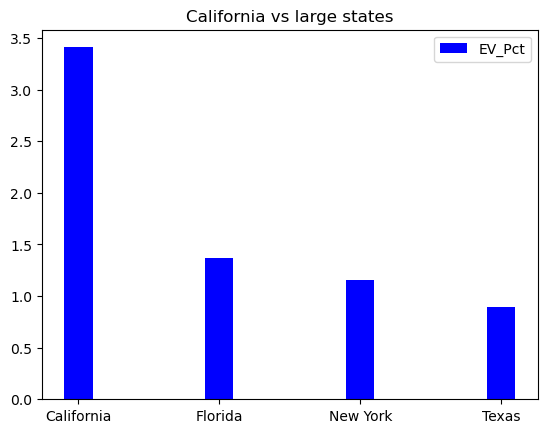

In [24]:
plt.bar(Result_EV['State'], Result_EV['EV_Pct'],
       width =0.2 , color ='blue',
        align= "center" 
       )
plt.title("California vs large states")
plt.legend(['EV_Pct'])
plt.savefig("California vs large states", dpi=300, bbox_inches='tight')
plt.show()